# Neural Network Regression (Diabetes)

In this lesson we build a **neural network regressor** (MLP) for the **Diabetes** dataset. We'll train an `MLPRegressor`, and evaluate with metrics and diagnostics. We'll also add a lightweight **uncertainty** estimate using an **ensemble** of MLPs.

**Learning objectives**
- Preprocess mixed features with `ColumnTransformer` (scaling + standardization).
- Train and tune an `MLPRegressor` with early stopping.
- Evaluate with $\text{RMSE}$, $\text{MAE}$, and $R^2$; create residual and calibration plots.
- Use a small **ensemble** of MLPs for predictive **mean** and **uncertainty (std)**.



## MLP for Regression (Theory)

A feed‑forward network with $L$ layers composes affine maps and nonlinearities:
$$
\hat{y} = f(x;\theta) = W^{(L)} a^{(L-1)} + b^{(L)}, \quad a^{(\ell)} = \phi\!\left(W^{(\ell)} a^{(\ell-1)} + b^{(\ell)}\right),
$$
with $a^{(0)} = x$, parameters $\theta = \{W^{(\ell)}, b^{(\ell)}\}$, and activation $\phi$ (e.g., ReLU).  
We minimize **mean squared error** (MSE):
$$
\mathcal{L}(\theta) = \frac{1}{n}\sum_{i=1}^n (y_i - f(x_i;\theta))^2.
$$

- **Early stopping** regularizes by halting training if validation loss stops improving.
- **Standardization** of numeric features helps optimization (well‑scaled inputs).
- **One‑hot encoding** for categorical variables lets the network learn from categories.


## Data: Diabetes (sklearn)

We use the built-in **Diabetes** dataset from `scikit-learn`, which contains 10 standardized numeric predictors and a continuous target `disease_progression` (a quantitative measure one year after baseline).

> No categorical features here — preprocessing only needs **standardization**.

In [2]:
# Load Diabetes dataset (built-in)
from sklearn.datasets import load_diabetes
import pandas as pd

data = load_diabetes(as_frame=True)
df = data.frame.copy()
df.rename(columns={'target': 'disease_progression'}, inplace=True)

print('Loaded Diabetes dataset. Shape:', df.shape)
df.head()

Loaded Diabetes dataset. Shape: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,disease_progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
# Split and build preprocessing pipeline (numeric-only)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
import numpy as np

target = 'disease_progression'
y = df[target].values
X = df.drop(columns=[target])

features = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(with_mean=True, with_std=True), features),
    ],
    remainder='drop'
)

features

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [4]:
# Baseline MLPRegressor with early stopping
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=1e-3,
    alpha=1e-4,                # L2 penalty
    max_iter=500,
    early_stopping=True,
    n_iter_no_change=20,
    validation_fraction=0.15,
    random_state=42
)

model = Pipeline([('prep', preprocess), ('mlp', mlp)])
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_train  = mean_absolute_error(y_train, y_pred_train)
mae_test   = mean_absolute_error(y_test, y_pred_test)
r2_train   = r2_score(y_train, y_pred_train)
r2_test    = r2_score(y_test, y_pred_test)

print(f"Train: RMSE={rmse_train:.1f}  MAE={mae_train:.1f}  R^2={r2_train:.3f}")
print(f"Test : RMSE={rmse_test:.1f}   MAE={mae_test:.1f}   R^2={r2_test:.3f}")

Train: RMSE=55.2  MAE=43.3  R^2=0.498
Test : RMSE=57.2   MAE=46.7   R^2=0.382


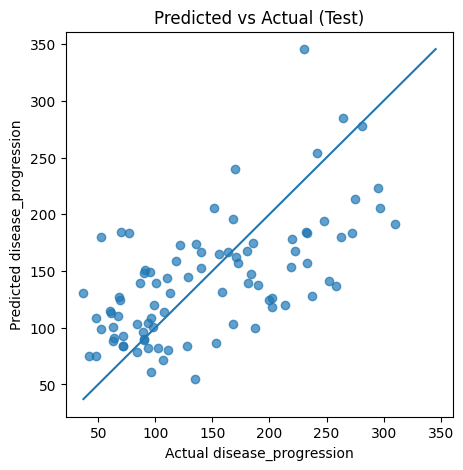

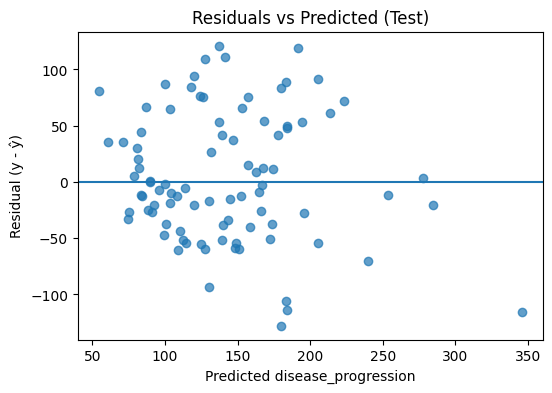

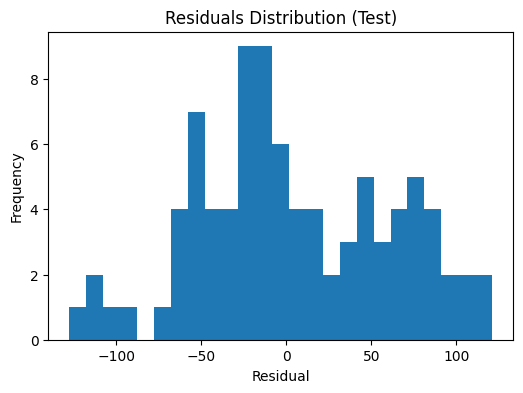

In [5]:
# Diagnostics
import matplotlib.pyplot as plt
import numpy as np

residuals = y_test - y_pred_test

# Predicted vs Actual
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred_test, alpha=0.7)
lo = min(y_test.min(), y_pred_test.min())
hi = max(y_test.max(), y_pred_test.max())
plt.plot([lo, hi], [lo, hi])
plt.xlabel("Actual disease_progression")
plt.ylabel("Predicted disease_progression")
plt.title("Predicted vs Actual (Test)")
plt.show()

# Residuals vs Predicted
plt.figure(figsize=(6,4))
plt.scatter(y_pred_test, residuals, alpha=0.7)
plt.axhline(0)
plt.xlabel("Predicted disease_progression")
plt.ylabel("Residual (y - ŷ)")
plt.title("Residuals vs Predicted (Test)")
plt.show()

# Residual histogram
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=25)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residuals Distribution (Test)")
plt.show()


## Lightweight Uncertainty via Ensembling

Train $K$ networks with different random seeds and average their predictions:
- The **ensemble mean** reduces variance.
- The **ensemble standard deviation** (per sample) provides a pragmatic **uncertainty proxy**.


In [6]:
# Train a small ensemble and compute mean/std of predictions
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
import numpy as np

K = 5
preds = []

for seed in range(K):
    mlp_k = MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        learning_rate_init=1e-3,
        alpha=1e-4,
        max_iter=500,
        early_stopping=True,
        n_iter_no_change=15,
        validation_fraction=0.15,
        random_state=seed
    )
    model_k = Pipeline([('prep', preprocess), ('mlp', mlp_k)])
    model_k.fit(X_train, y_train)
    preds.append(model_k.predict(X_test))

preds = np.vstack(preds)              # shape (K, n_test)
y_pred_mean = preds.mean(axis=0)      # ensemble mean
y_pred_std  = preds.std(axis=0)       # ensemble std (uncertainty proxy)

# Compare single vs ensemble
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
rmse_ens = np.sqrt(mean_squared_error(y_test, y_pred_mean))
mae_ens  = mean_absolute_error(y_test, y_pred_mean)
r2_ens   = r2_score(y_test, y_pred_mean)

print(f"Ensemble: RMSE={rmse_ens:.1f}  MAE={mae_ens:.1f}  R^2={r2_ens:.3f}")
print("Per-sample prediction std (first 10):", np.round(y_pred_std[:10], 1))

Ensemble: RMSE=54.4  MAE=44.1  R^2=0.442
Per-sample prediction std (first 10): [ 9.7  3.5  9.4  8.2  7.4  4.  10.   6.9  8.8 10.5]


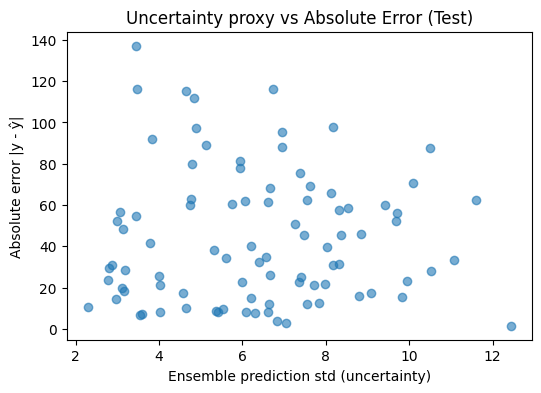

In [7]:
# Visualize uncertainty: error vs ensemble std
import matplotlib.pyplot as plt
import numpy as np

abs_err = np.abs(y_test - y_pred_mean)

plt.figure(figsize=(6,4))
plt.scatter(y_pred_std, abs_err, alpha=0.6)
plt.xlabel("Ensemble prediction std (uncertainty)")
plt.ylabel("Absolute error |y - ŷ|")
plt.title("Uncertainty proxy vs Absolute Error (Test)")
plt.show()



## Exercises

1. **Hyperparameters:** Try `hidden_layer_sizes=(128, 64)` and `alpha=1e-3`. Does $R^2$ improve on test?
2. **Input transforms:** Add polynomial features for `bmi` (or interactions) before the MLP. Any gain?
3. **Uncertainty:** Increase the ensemble size $K$ to 10–20. Does the std correlate better with errors?
